**HADM 5285 Mini Project 2: Nomis Solutions Case Study**

In [1]:
# Importing the libraries
# Update as needed

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load in the data

# The downloaded data will be in the format of .xlsx. You can use the following code to read in the data.
loan_data = pd.read_excel('CU262-XLS-ENG.xlsx', sheet_name = "e_Car_Data_for_Case")

# Use the following code to drop the null values in the data.
data_clean = loan_data.dropna()

In [3]:
# Let's look at the first 10 rows of the data
data_clean.head(10)

,Tier,FICO,Approve Date,Term,Amount,Previous Rate,Car Type,Competition rate,Accept?,Rate,Cost of Funds,Partner Bin
0,3.0,695.0,2002-07-01,72.0,35000.0,,N,6.25,0.0,7.49,1.8388,1.0
1,1.0,751.0,2002-07-01,60.0,40000.0,,N,5.65,0.0,5.49,1.8388,3.0
2,1.0,731.0,2002-07-01,60.0,18064.0,,N,5.65,0.0,5.49,1.8388,3.0
3,4.0,652.0,2002-07-01,72.0,15415.0,,N,6.25,0.0,8.99,1.8388,3.0
4,1.0,730.0,2002-07-01,48.0,32000.0,,N,5.65,0.0,5.49,1.8388,1.0
5,2.0,725.0,2002-07-01,36.0,10000.0,,N,4.95,0.0,5.79,1.8388,3.0
6,1.0,808.0,2002-07-01,72.0,19000.0,,N,6.25,0.0,6.59,1.8388,3.0
7,1.0,779.0,2002-07-01,48.0,25000.0,,U,5.85,0.0,5.85,1.8388,3.0
8,4.0,664.0,2002-07-01,72.0,7500.0,,N,6.25,0.0,8.99,1.8388,3.0
9,2.0,706.0,2002-07-01,60.0,22000.0,,N,5.65,0.0,5.79,1.8388,3.0


**Part 1**: Briefly describe e-Car’s business model in a few sentences. What is the main
decision e-Car must make when offering loans to its customers? What are some of the main sources of
uncertainty faced by e-Car’s lending business?

- e-Car’s business model involves evaluating auto loan applications online. For approved customers, e-Car offers a loan at a specific interest rate (APR). Upon seeing the offer, the customer can either accept the loan (resulting in funding) or reject it. e-Car earns revenue primarily from the interest charged on funded loans. Currently, pricing is based on factors such as FICO score, loan term, and loan type, but lacks a data-driven, analytical approach.

- The main decision e-Car must make when offering loans is deciding what interest rate (APR) to charge each approved customer. This decision involves balancing the trade-off between higher revenue per loan (from higher rates) and a lower probability of customer acceptance. Additionally, e-Car must consider the cost of funds, since the interest charged is not pure profit.

- Some main sources of uncertainty faced by e-Car’s lending business include:
    1. Customer acceptance behavior (whether a customer accepts a given rate)
    2. Customer price sensitivity (how demand responds to changes in rates)
    3. Credit risk (the likelihood of borrower default)
    4. Cost of funds (which affects the profitability of loans)
    5. Competitive environment (rates offered by other lenders)
    6. Customer heterogeneity (differences in risk and willingness to pay across borrowers)

**IMPORTANT** Parts 2-8 focus on a particular customer segment: Restrict your focus to the customer segment
who are approved for loans that have terms of 60 months, looking to buy used cars, for loan amounts
strictly less than $25,000, and FICO scores between 680 and 720 (not including 680 and 720).

In [4]:
# Task: Restrict your focus to the customer segment who are approved for loans that have terms of 60 months, looking to buy used cars,
# for loan amounts strictly less than $25,000, and FICO scores between 680 and 720 (not including 680 and 720).
# Use boolean indexing and keep it concise.

In [5]:
# Select the particular customer segment from the cleaned data
data_segmented = data_clean[
    (data_clean["Term"] == 60) &
    (data_clean["Car  Type"] == "U") &
    (data_clean["Amount"] < 25000) &
    (data_clean["FICO"] > 680) &
    (data_clean["FICO"] < 720)
].copy()

data_segmented

,Tier,FICO,Approve Date,Term,Amount,Previous Rate,Car Type,Competition rate,Accept?,Rate,Cost of Funds,Partner Bin
31,2.0,715.0,2002-07-01,60.0,21000.00,,U,5.85,0.0,6.19,1.8388,1.0
95,2.0,701.0,2002-07-01,60.0,16510.00,,U,5.85,1.0,6.19,1.8388,1.0
137,2.0,705.0,2002-07-01,60.0,13024.26,,U,5.85,1.0,6.19,1.8388,2.0
191,2.0,700.0,2002-07-02,60.0,16500.00,,U,5.85,1.0,6.19,1.8388,2.0
302,2.0,708.0,2002-07-02,60.0,11369.33,,U,5.85,1.0,6.19,1.8388,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
207937,3.0,681.0,2004-11-16,60.0,24999.99,,U,4.85,0.0,8.49,2.1270,3.0
207983,3.0,689.0,2004-11-16,60.0,16000.00,,U,4.85,0.0,8.49,2.1270,3.0
208024,2.0,716.0,2004-11-16,60.0,19999.99,,U,4.85,0.0,6.59,2.1270,3.0
208026,3.0,681.0,2004-11-16,60.0,16899.99,,U,4.85,0.0,8.49,2.1270,2.0


**Part 2**: Next, create a new column called AcceptRevenue, where AcceptRevenue =
Rate*Amount/100. Then create a scatterplot with trendline of “Accept?” vs “Rate” and another plot of
“AcceptRevenue” vs “Rate”. You can use lmplot from the seaborn package. See an example below. What
do your plots suggest is the main trade-off faced by e-Car when making loan offers?

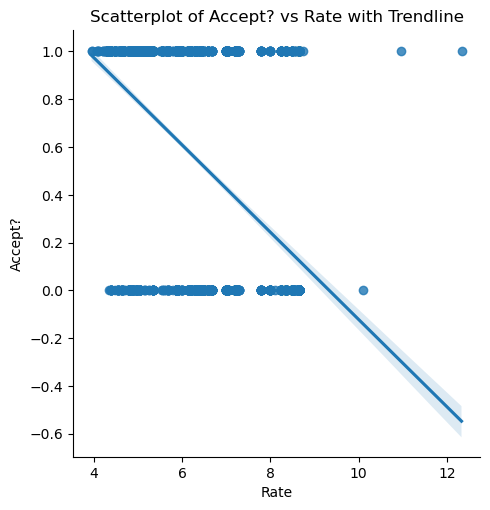

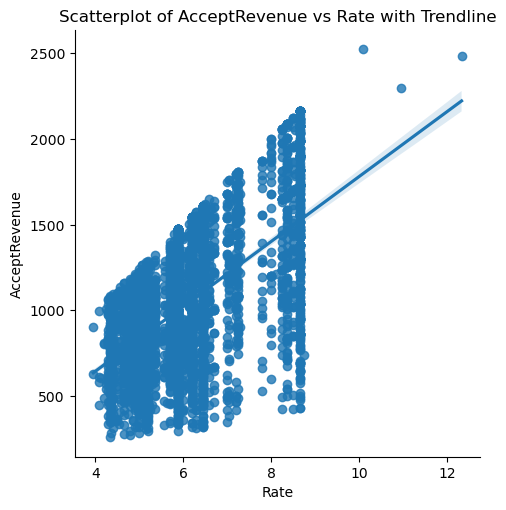

In [6]:
# Create a new column called AcceptRevenue
data_segmented["AcceptRevenue"] = data_segmented["Rate"] * data_segmented["Amount"] / 100

# Plot 1: Accept? vs Rate
sns.lmplot(x='Rate', y='Accept?', data = data_segmented)
plt.title('Scatterplot of Accept? vs Rate with Trendline')

# Plot 2: AcceptRevenue vs Rate
sns.lmplot(x="Rate", y="AcceptRevenue", data = data_segmented)
plt.title('Scatterplot of AcceptRevenue vs Rate with Trendline')

plt.show()

The plots suggest that e-Car faces a trade-off between charging higher interest rates to earn more revenue per loan and offering lower interest rates to increase the probability that customers accept the loan, thus requiring a balance between margin and volume.

**Part 3**: Create a histogram of the rates offered by e-Car, setting a bin width of 0.5%. Are
there outliers? Remove the top 2% and bottom 2% for all the subsequent analysis. Approximately what rate
is most commonly offered by eCar for this customer segment?

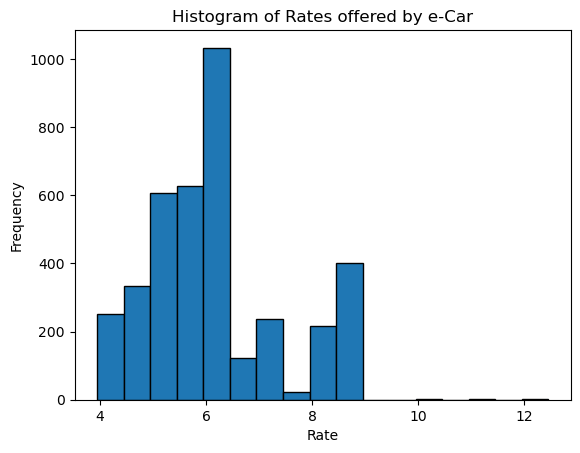

In [7]:
# Histogram with 0.5 bin width
w = 0.5
bins = np.arange(data_segmented['Rate'].min(), data_segmented['Rate'].max() + w, w)
plt.hist(data_segmented['Rate'], bins=bins, edgecolor='black')
plt.xlabel("Rate")
plt.ylabel("Frequency")
plt.title("Histogram of Rates offered by e-Car")
plt.show()

Yes, there are outliers. While most rates are concentrated between around 4% and 7%, there are a few observations at much higher rates (around 10%–12%), which appear infrequent and far from the main distribution, indicating the presence of outliers.

In [8]:
# Task: Remove the bottom 2% and top 2% of the segmented data using boolean indexing (square brackets).

In [9]:
# Remove bottom 2% and top 2%
low = data_segmented["Rate"].quantile(0.02)
high = data_segmented["Rate"].quantile(0.98)

data_trimmed = data_segmented[
    (data_segmented["Rate"] >= low) &
    (data_segmented["Rate"] <= high)
].copy()

print(f"Lower bound (2nd percentile): {low:.2f}")
print(f"Upper bound (98th percentile): {high:.2f}")
print(data_trimmed.shape)

Lower bound (2nd percentile): 4.34
Upper bound (98th percentile): 8.65
(3805, 13)


In [10]:
# Task: Generate another histogram using data_trimmed. Make sure to show the bin ranges clearly on the histogram.

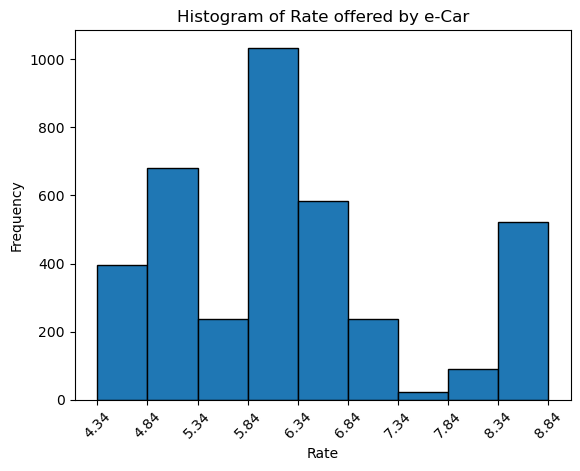

In [11]:
# Histogram with 0.5 bin width after removing the bottom 2% and top 2%
w = 0.5
bins = np.arange(data_trimmed["Rate"].min(), data_trimmed["Rate"].max() + w, w)
plt.hist(data_trimmed["Rate"], bins=bins, edgecolor="black")
plt.xlabel("Rate")
plt.ylabel("Frequency")
plt.title("Histogram of Rate offered by e-Car")
plt.xticks(bins, rotation=45)  # show bin edges
plt.show()

The most commonly offered rate appears to be approximately 5.84%–6.34%, with the center around 6.09%.

**Part 4**: Use logistic regression to predict the probability that a customer accepts the loan
offer using only the Rate feature. Create a new column called ProbAccept which represents the predicted
probability of the customer accepting the loan offer based on their offered rate. Next, add another column
called ExpectedRevenue, where ExpectedRevenue = (ProbAccept * Rate * Amount)/100. What is the
average of the ExpectedRevenue column? In one sentence, what does this value represent? For this
part in particular, with a little abuse of the machine learning process, train your logistic regression
model and predict using the entire dataset without splitting.

In [12]:
# Import logistic regression
from sklearn.linear_model import LogisticRegression

In [13]:
# Use logistic regression to predict whether the customer accepts the loan offer using only Rate
X = data_trimmed[["Rate"]]
y = data_trimmed["Accept?"]

logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(X, y)

# Create a new column called ProbAccept
data_trimmed["ProbAccept"] = logit_model.predict_proba(X)[:, 1]

# Create a new column called ExpectedRevenue
data_trimmed["ExpectedRevenue"] = (
    data_trimmed["ProbAccept"] * data_trimmed["Rate"] * data_trimmed["Amount"] / 100
)

# Average expected revenue
avg_expected_revenue = data_trimmed["ExpectedRevenue"].mean()

print(f"Average Expected Revenue: {avg_expected_revenue:.2f}")
data_trimmed[["Rate", "Amount", "Accept?", "ProbAccept", "ExpectedRevenue"]].head()

Average Expected Revenue: 550.59


,Rate,Amount,Accept?,ProbAccept,ExpectedRevenue
31,6.19,21000.00,0.0,0.577407,750.571180
95,6.19,16510.00,1.0,0.577407,590.091913
137,6.19,13024.26,1.0,0.577407,465.506390
191,6.19,16500.00,1.0,0.577407,589.734499
302,6.19,11369.33,1.0,0.577407,406.356735


The average ExpectedRevenue is 550.59. This value represents the average expected revenue per customer in this segment, where each loan’s revenue is weighted by the predicted probability of acceptance.

**Part 5**: Based on the results of your logistic regression model, is there an alternative rate
that might boost expected revenue when offered to all customers in the segment? What rate do you
recommend, and what is the potential revenue improvement associated with your recommendation?

In [14]:
# Create candidate rates and compute average expected revenue at each rate
candidate_rates = np.arange(data_trimmed["Rate"].min(), data_trimmed["Rate"].max() + 0.01, 0.01)

avg_revenue_list = []
for r in candidate_rates:
    prob_accept_r = logit_model.predict_proba(pd.DataFrame({"Rate": [r]}))[0, 1]
    expected_revenue_r = prob_accept_r * r * data_trimmed["Amount"] / 100
    avg_revenue_list.append(expected_revenue_r.mean())

rate_revenue_df = pd.DataFrame({
    "Rate": candidate_rates,
    "AverageExpectedRevenue": avg_revenue_list
})

rate_revenue_df.head()

,Rate,AverageExpectedRevenue
0,4.34,650.412396
1,4.35,651.195457
2,4.36,651.970328
3,4.37,652.736957
4,4.38,653.495287


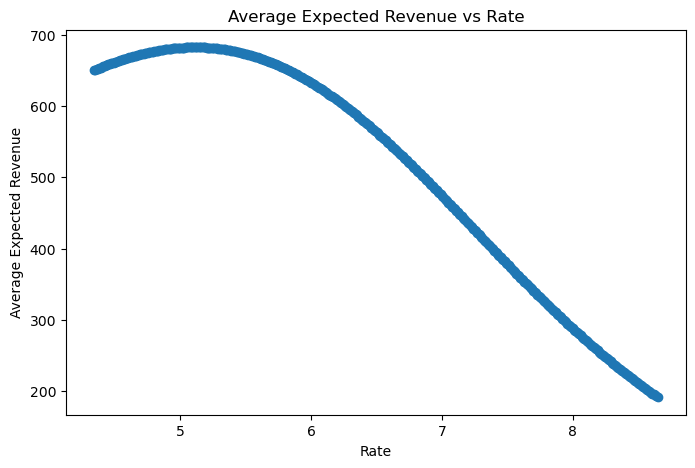

In [15]:
# Plot average expected revenue against rate
plt.figure(figsize=(8, 5))
plt.scatter(rate_revenue_df["Rate"], rate_revenue_df["AverageExpectedRevenue"])
plt.xlabel("Rate")
plt.ylabel("Average Expected Revenue")
plt.title("Average Expected Revenue vs Rate")
plt.show()

In [16]:
# Find the rate that maximizes average expected revenue
best_row = rate_revenue_df.loc[rate_revenue_df["AverageExpectedRevenue"].idxmax()]

best_rate = best_row["Rate"]
best_avg_revenue = best_row["AverageExpectedRevenue"]

current_avg_revenue = data_trimmed["ExpectedRevenue"].mean()
improvement = best_avg_revenue - current_avg_revenue
improvement_pct = improvement / current_avg_revenue * 100

print(f"Recommended rate: {best_rate:.2f}%")
print(f"Average expected revenue at recommended rate: {best_avg_revenue:.2f}")
print(f"Current average expected revenue: {current_avg_revenue:.2f}")
print(f"Potential improvement per customer: {improvement:.2f}")
print(f"Percentage improvement: {improvement_pct:.2f}%")

Recommended rate: 5.11%
Average expected revenue at recommended rate: 682.80
Current average expected revenue: 550.59
Potential improvement per customer: 132.21
Percentage improvement: 24.01%


In [17]:
# Total revenue improvement
total_current_revenue = data_trimmed["ExpectedRevenue"].sum()
total_new_revenue = best_avg_revenue * len(data_trimmed)
total_improvement = total_new_revenue - total_current_revenue

print(f"Total potential revenue improvement: {total_improvement:.2f}")

Total potential revenue improvement: 503043.06


Yes. Based on the logistic regression results, offering a uniform rate of 5.11% to all customers in this segment would maximize expected revenue. At this rate, the average expected revenue rises from 550.59 to 682.80, an increase of 132.21 per customer or 24.01%. For the full segment, this implies a total potential revenue improvement of $503,043.06.

**Part 6:** Let’s refine the prediction model by including more features and experiment with other ML models. Try out at least four different ML models other than Logistic regression using the features FICO score, Loan amount approved, Competition rate, Rate, Cost of Funds, and partner bin to
predict whether a customer accepts the loan offer. Required steps:

1) Split your data into training, validation, and testing sets. You can decide the proportion, as long as it’s reasonable

In [18]:
# Data Preparation & Splitting
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Feature selection
features = ['FICO', 'Amount', 'Competition rate', 'Rate', 'Cost of Funds', 'Partner Bin']
X = data_trimmed[features]
y = data_trimmed['Accept?']

# 60% Train, 20% Validation, 20% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=123, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=123, stratify=y_temp
)

# Manually define categorical and numeric columns
categorical_cols = ['Partner Bin']
numeric_cols = ['FICO', 'Amount', 'Competition rate', 'Rate', 'Cost of Funds']

# Define preprocessing for numeric columns
numeric_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='mean'))]
)

# Define preprocessing for categorical columns
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)

# Apply preprocessing
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)


print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 2283, Val: 761, Test: 761


2. Feature scaling whenever necessary
3. Hyperparameter tuning using cross validation (If you choose ANN, you only need to fine tune the
number of epochs without using cross validation like we did in class)

In [19]:
# Setup (Scaling + CV)
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

cv_fold = KFold(n_splits=5, shuffle=True, random_state=123)
model_results = {}

In [20]:
# Model 1 — SVM (with scaling + CV)
from sklearn.svm import SVC

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=123))
])

# Expanded parameter grid for C, combining previous values with those from the example
svm_params = {
    'svm__C': [0.001, 0.005, 0.01, 0.02, 0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

svm_grid = GridSearchCV(
    svm_pipe,
    svm_params,
    cv=cv_fold,
    scoring='roc_auc',
    n_jobs=-1 # Use all available cores for parallel processing
)

# X_train and y_train are already prepared (preprocessed and scaled implicitly by the pipeline)
svm_grid.fit(X_train, y_train)
model_results['SVM'] = svm_grid

In [21]:
# Model 2 — Decision Tree (CV)
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    'max_depth': [3, 5, 7, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=123),
    dt_params,
    cv=cv_fold,
    scoring='roc_auc'
)

dt_grid.fit(X_train, y_train)
model_results['Decision Tree'] = dt_grid

In [22]:
# Model 3 — Random Forest (CV)
from sklearn.ensemble import RandomForestClassifier

# Define the KFold cross-validation strategy with random_state=0 as per best practices
cv_rf = KFold(n_splits=5, shuffle=True, random_state=0)

rf_params = {
    'n_estimators': [300, 400, 500], # Search over [300, 400, 500] as per best practices
    'max_depth': [5, 10, None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=0), # Use random_state=0 as per best practices
    rf_params,
    cv=cv_rf, # Use the new cv_rf with random_state=0
    scoring='roc_auc', # Use AUC as performance metric
    n_jobs=-1, # Use all available cores
    verbose=1 # Add verbose output
)

rf_grid.fit(X_train, y_train)
model_results['Random Forest'] = rf_grid

# Print best parameters and best score as per best practices
print(f"Best tree number (n_estimators): {rf_grid.best_params_['n_estimators']}")
print(f"Best cross-validation AUC: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best tree number (n_estimators): 400
Best cross-validation AUC: 0.8914


In [23]:
# Model 4 — ANN using TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

# Scale data for ANN
# ANN is sensitive to feature scale, so we scale the preprocessed features.
ann_scaler = StandardScaler()
X_train_ann = ann_scaler.fit_transform(X_train)
X_val_ann = ann_scaler.transform(X_val)
X_test_ann = ann_scaler.transform(X_test)

# Set random seed for reproducibility
tf.random.set_seed(123)

# Tune number of epochs only, as required
ann_epochs = [10, 20, 50, 100]
ann_results = {}

for epoch in ann_epochs:
    
    # Build ANN model
    nn = Sequential()
    nn.add(Dense(10, activation='relu', input_shape=(X_train_ann.shape[1],)))
    nn.add(Dense(1, activation='sigmoid'))
    
    # Compile ANN model
    nn.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # Train ANN model
    nn.fit(
        X_train_ann,
        y_train,
        epochs=epoch,
        validation_data=(X_val_ann, y_val),
        verbose=0
    )
    
    # Predict probabilities on validation set
    val_probs = nn.predict(X_val_ann, verbose=0).ravel()
    val_auc = roc_auc_score(y_val, val_probs)
    
    ann_results[epoch] = (nn, val_auc)

# Select best ANN based on validation AUC
best_epoch = max(ann_results, key=lambda x: ann_results[x][1])
best_ann_model = ann_results[best_epoch][0]
best_ann_val_auc = ann_results[best_epoch][1]

model_results['ANN'] = best_ann_model

print(f"Best ANN Epoch: {best_epoch}")
print(f"Best ANN Validation AUC: {best_ann_val_auc:.4f}")

2026-04-29 13:42:18.266410: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Best ANN Epoch: 50
Best ANN Validation AUC: 0.8684


In [24]:
# Model Comparison (Validation Performance)
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

comparison_df = pd.DataFrame(columns=['Train AUC', 'Val AUC'])

for name, model in model_results.items():
    
    if name == 'ANN':
        # ANN uses scaled data
        train_probs = model.predict(X_train_ann, verbose=0).ravel()
        val_probs = model.predict(X_val_ann, verbose=0).ravel()
    else:
        # sklearn models use regular preprocessed data
        train_probs = model.predict_proba(X_train)[:, 1]
        val_probs = model.predict_proba(X_val)[:, 1]
    
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    
    comparison_df.loc[name] = [train_auc, val_auc]

print("Model Comparison (AUC):")
print(comparison_df)

Model Comparison (AUC):
               Train AUC   Val AUC
SVM             0.890742  0.861984
Decision Tree   0.904154  0.863398
Random Forest   0.988341  0.884020
ANN             0.887328  0.868351


4. Select the best model.

In [25]:
# Select Best Model
best_model_name = comparison_df['Val AUC'].idxmax()
best_model = model_results[best_model_name]

print(f"Best Model: {best_model_name}")

Best Model: Random Forest


In [26]:
# Final Test Evaluation
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

if best_model_name == 'ANN':
    # ANN uses scaled test data
    test_probs = best_model.predict(X_test_ann, verbose=0).ravel()
    test_pred = (test_probs >= 0.5).astype(int)
else:
    # sklearn models use regular preprocessed test data
    test_probs = best_model.predict_proba(X_test)[:, 1]
    test_pred = best_model.predict(X_test)

test_auc = roc_auc_score(y_test, test_probs)
test_acc = accuracy_score(y_test, test_pred)

print(f"Test AUC: {test_auc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, test_pred))

Test AUC: 0.8951
Test Accuracy: 0.8160

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.81      0.79       329
         1.0       0.85      0.82      0.84       432

    accuracy                           0.82       761
   macro avg       0.81      0.81      0.81       761
weighted avg       0.82      0.82      0.82       761



**Model Selection**

In determining the "best" model, we prioritized a balance between predictive accuracy, as measured by the ROC AUC score, and practical considerations such as potential for interpretability and computational efficiency. Given that our dataset is relatively modest in size, all models executed quickly, meaning computational efficiency was not a restrictive factor in this specific selection process.

The **Random Forest** model emerged as the best performer, achieving the highest validation AUC score (0.884). After selecting Random Forest as the best model, its performance on the unseen test set was evaluated, yielding a **Test AUC of 0.8951** and a **Test Accuracy of 0.8160**. This robust performance can be attributed to several factors inherent in ensemble learning methods like Random Forest:

1.  **Reduced Variance:** Random Forests build multiple decision trees and average their predictions. This bagging technique effectively reduces overfitting and variance, leading to better generalization on unseen data compared to a single decision Tree.
2.  **Handling Non-linear Relationships:** By aggregating the results of many deep decision trees, Random Forests can capture complex, non-linear relationships between features and the target variable without requiring explicit feature engineering for interaction terms.
3.  **Feature Importance:** Although not explicitly plotted in the notebook, Random Forests intrinsically provide a measure of feature importance, which can offer some level of interpretability regarding which features contribute most to the prediction.

While other models like **SVM** and **Decision Trees** also performed reasonably well, they didn't quite match the Random Forest's validation AUC. Decision Trees, while highly interpretable, can suffer from high variance (overfitting) if not carefully pruned. The **Artificial Neural Network (ANN)**, despite its potential for learning complex patterns, showed the lowest validation AUC among the models tested, suggesting it might require more extensive tuning or a larger dataset to fully realize its potential in this specific context. Therefore, considering its superior performance and balanced characteristics, Random Forest was selected as the optimal model for predicting loan acceptance in this scenario.

**Part 7**: Parts 7 and 8 are follow-ups of Part 5, and we will leverage data analytics and ML to optimize APR and boost revenue more scientifically. Let’s start with optimizing APR for a single customer.

Selected Customer Information:


,FICO,Amount,Competition rate,Rate,Cost of Funds,Partner Bin
97843,695.0,13561.95,4.79,5.69,1.115,1.0


Original quoted rate: 5.69%
Loan amount: $13,561.95

Part 7 Results:
Best model used: Random Forest
Original quoted rate: 5.69%
Original predicted acceptance probability: 0.9939
Original expected revenue: $766.97

Optimal rate: 8.10%
Optimal predicted acceptance probability: 0.7873
Optimal expected revenue: $864.88

Revenue improvement: $97.90
Percentage improvement: 12.77%


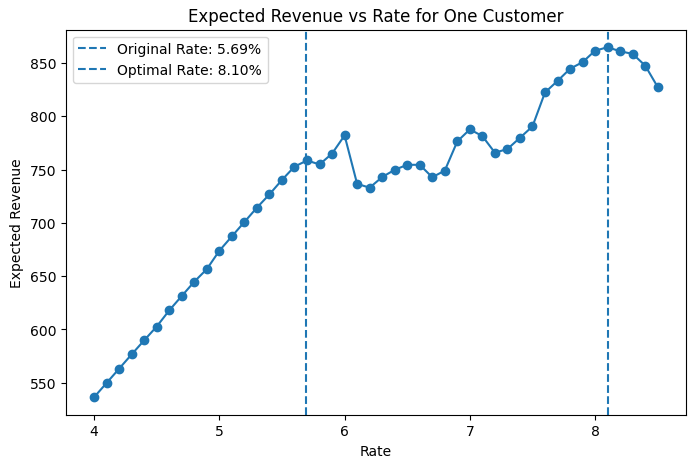

,Rate,ProbAccept,ExpectedRevenue
41,8.1,0.787313,864.877528
40,8.0,0.794157,861.625196
42,8.2,0.774271,861.050998
43,8.3,0.762780,858.616866
39,7.9,0.794157,850.854881
44,8.4,0.744043,847.616566
38,7.8,0.798464,844.640414
37,7.7,0.797908,833.231541
45,8.5,0.717848,827.510420
36,7.6,0.797908,822.410352


In [27]:
# Prompt used for ChatGPT:
# Based on the Nomis Solutions Mini Project 2 description, generate Python code for Part 7.
# The code should use the best model selected in Part 6 to optimize the APR for a single customer
# from the test set. It should vary the Rate from 4.0 to 8.5 in increments of 0.1, predict the
# acceptance probability for each rate, calculate expected revenue using
# ExpectedRevenue = (ProbAccept * Rate * Amount) / 100, identify the rate that maximizes expected
# revenue, and compare the optimal rate with the customer's original quoted rate.
# The code should work for both sklearn models and TensorFlow/Keras ANN models.

# Part 7: Optimize APR for a single customer from the test set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Helper function: predict probability for sklearn or Keras model
# ------------------------------------------------------------

def get_prob_accept(model, X_processed):
    """
    Return predicted probability of Accept? = 1.
    Works for both sklearn models and TensorFlow/Keras ANN models.
    If the best model is ANN, apply ann_scaler before prediction.
    """
    if best_model_name == 'ANN':
        X_processed_scaled = ann_scaler.transform(X_processed)
        return model.predict(X_processed_scaled, verbose=0).ravel()
    else:
        return model.predict_proba(X_processed)[:, 1]

# ------------------------------------------------------------
# Step 1: Recreate the raw train/validation/test split
# This uses the same split logic and random_state as Part 6.
# ------------------------------------------------------------

features = ['FICO', 'Amount', 'Competition rate', 'Rate', 'Cost of Funds', 'Partner Bin']

X_raw = data_trimmed[features].copy()
y_raw = data_trimmed['Accept?'].copy()

X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.40,
    random_state=123,
    stratify=y_raw
)

X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw,
    y_temp_raw,
    test_size=0.50,
    random_state=123,
    stratify=y_temp_raw
)

# ------------------------------------------------------------
# Step 2: Randomly select one customer from the test set
# ------------------------------------------------------------

single_customer = X_test_raw.sample(n=1, random_state=123).copy()

original_rate = single_customer['Rate'].iloc[0]
loan_amount = single_customer['Amount'].iloc[0]

print("Selected Customer Information:")
display(single_customer)

print(f"Original quoted rate: {original_rate:.2f}%")
print(f"Loan amount: ${loan_amount:,.2f}")

# ------------------------------------------------------------
# Step 3: Vary the Rate from 4.0 to 8.5 in increments of 0.1
# ------------------------------------------------------------

candidate_rates = np.round(np.arange(4.0, 8.5 + 0.1, 0.1), 2)

q7_results = []

for r in candidate_rates:
    customer_copy = single_customer.copy()
    customer_copy['Rate'] = r
    
    # Apply the same preprocessing object from Part 6
    customer_processed = preprocessor.transform(customer_copy)
    
    # Predict acceptance probability
    prob_accept = get_prob_accept(best_model, customer_processed)[0]
    
    # Calculate expected revenue
    expected_revenue = (prob_accept * r * loan_amount) / 100
    
    q7_results.append({
        'Rate': r,
        'ProbAccept': prob_accept,
        'ExpectedRevenue': expected_revenue
    })

q7_results_df = pd.DataFrame(q7_results)

# ------------------------------------------------------------
# Step 4: Identify the optimal rate
# ------------------------------------------------------------

best_row = q7_results_df.loc[q7_results_df['ExpectedRevenue'].idxmax()]

optimal_rate = best_row['Rate']
optimal_prob_accept = best_row['ProbAccept']
optimal_expected_revenue = best_row['ExpectedRevenue']

# ------------------------------------------------------------
# Step 5: Calculate expected revenue at the original quoted rate
# ------------------------------------------------------------

original_customer = single_customer.copy()
original_customer_processed = preprocessor.transform(original_customer)

original_prob_accept = get_prob_accept(best_model, original_customer_processed)[0]
original_expected_revenue = (original_prob_accept * original_rate * loan_amount) / 100

revenue_improvement = optimal_expected_revenue - original_expected_revenue
revenue_improvement_pct = revenue_improvement / original_expected_revenue * 100

# ------------------------------------------------------------
# Step 6: Print results
# ------------------------------------------------------------

print("\nPart 7 Results:")
print(f"Best model used: {best_model_name}")
print(f"Original quoted rate: {original_rate:.2f}%")
print(f"Original predicted acceptance probability: {original_prob_accept:.4f}")
print(f"Original expected revenue: ${original_expected_revenue:,.2f}")

print(f"\nOptimal rate: {optimal_rate:.2f}%")
print(f"Optimal predicted acceptance probability: {optimal_prob_accept:.4f}")
print(f"Optimal expected revenue: ${optimal_expected_revenue:,.2f}")

print(f"\nRevenue improvement: ${revenue_improvement:,.2f}")
print(f"Percentage improvement: {revenue_improvement_pct:.2f}%")

# ------------------------------------------------------------
# Step 7: Plot Expected Revenue vs Rate
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(q7_results_df['Rate'], q7_results_df['ExpectedRevenue'], marker='o')
plt.axvline(original_rate, linestyle='--', label=f'Original Rate: {original_rate:.2f}%')
plt.axvline(optimal_rate, linestyle='--', label=f'Optimal Rate: {optimal_rate:.2f}%')
plt.xlabel('Rate')
plt.ylabel('Expected Revenue')
plt.title('Expected Revenue vs Rate for One Customer')
plt.legend()
plt.show()

# Show the top 10 rates by expected revenue
q7_results_df.sort_values(by='ExpectedRevenue', ascending=False).head(10)

**Analysis**:

1. Is the optimal rate the same as the rate originally quoted to the customer?

No. The original quoted rate for this customer was **5.69%**, while the model-selected optimal rate was **8.10%**. This means the original rate was lower than the revenue-maximizing rate predicted by the model.

2. How does the expected revenue at the optimal rate compare to that at the quoted rate?

At the original quoted rate of 5.69%, the predicted acceptance probability was **0.9939**, and the expected revenue was **766.97 dollars**. At the optimal rate of 8.10%, the predicted acceptance probability decreased to 0.7873, but the expected revenue increased to **864.88 dollars**. Therefore, the optimal rate increases expected revenue by **97.90 dollars**, or 12.77%.

3. Based on these findings, is there an opportunity to enhance revenue generation through the application of machine learning?

Yes. For this selected customer, the machine learning model suggests that e-Car could charge a higher APR while still maintaining a reasonably high probability of acceptance. Although the acceptance probability falls when the rate increases, the higher margin more than offsets the lower acceptance probability, leading to higher expected revenue. This suggests that machine learning can help e-Car identify customer-specific optimal rates and improve revenue compared with using the original quoted rate.

**Part 8**: Use the same method in Part 7 to determine the optimal rate for every single customer in the testing set. Calculate the optimal expected revenue and find out how much total revenue can be improved by applying the optimal rates compared to the quoted rates

In [28]:
# Part 8: Optimized vectorized version

candidate_rates = np.round(np.arange(4.0, 8.5 + 0.1, 0.1), 2)
n_rates     = len(candidate_rates)
n_customers = len(X_test_raw)
amounts      = X_test_raw['Amount'].values
original_rates_arr = X_test_raw['Rate'].values

# Step 1: Stack all (customer x rate) combos into one big DataFrame
# n_rates DataFrames each with n_customers rows → one big (n_rates * n_customers) DataFrame
all_copies = []
for r in candidate_rates:
    temp = X_test_raw.copy()
    temp['Rate'] = r
    all_copies.append(temp)

X_big = pd.concat(all_copies, ignore_index=True)

# Step 2: Preprocess & predict in one shot
X_big_processed = preprocessor.transform(X_big)
all_probs = get_prob_accept(best_model, X_big_processed)

# Step 3: Reshape to (n_rates, n_customers)
prob_matrix = all_probs.reshape(n_rates, n_customers)

# Revenue matrix: (n_rates, n_customers)
rev_matrix = (prob_matrix * candidate_rates[:, np.newaxis] * amounts[np.newaxis, :]) / 100

# Step 4: Find optimal rate per customer
optimal_idx = np.argmax(rev_matrix, axis=0)
optimal_rates = candidate_rates[optimal_idx]
optimal_revenues = rev_matrix[optimal_idx, np.arange(n_customers)]

# Step 5: Revenue at original quoted rates (one single prediction call)
X_orig_processed = preprocessor.transform(X_test_raw)
orig_probs = get_prob_accept(best_model, X_orig_processed)
orig_revenues    = (orig_probs * original_rates_arr * amounts) / 100

# Build results DataFrame
q8_df = pd.DataFrame({
    'OriginalRate':       original_rates_arr,
    'OptimalRate':        optimal_rates,
    'OriginalRevenue':    orig_revenues,
    'OptimalRevenue':     optimal_revenues,
    'RevenueImprovement': optimal_revenues - orig_revenues
})


In [29]:
# --- Summary ---
total_original_revenue   = q8_df['OriginalRevenue'].sum()
total_optimal_revenue    = q8_df['OptimalRevenue'].sum()
total_improvement        = q8_df['RevenueImprovement'].sum()
pct_improvement          = (total_improvement / total_original_revenue) * 100

print("=" * 50)
print("Part 8 Results")
print("=" * 50)
print(f"Number of test customers:       {len(q8_df)}")
print(f"Total revenue (quoted rates):   ${total_original_revenue:,.2f}")
print(f"Total revenue (optimal rates):  ${total_optimal_revenue:,.2f}")
print(f"Total revenue improvement:      ${total_improvement:,.2f}")
print(f"Percentage improvement:         {pct_improvement:.2f}%")


Part 8 Results
Number of test customers:       761
Total revenue (quoted rates):   $383,213.32
Total revenue (optimal rates):  $553,096.93
Total revenue improvement:      $169,883.61
Percentage improvement:         44.33%


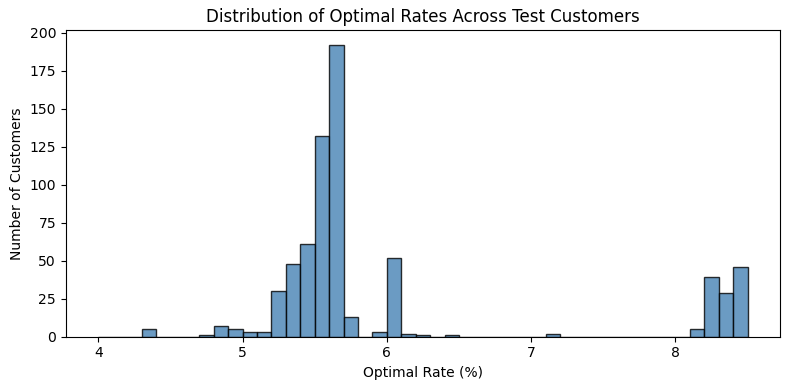

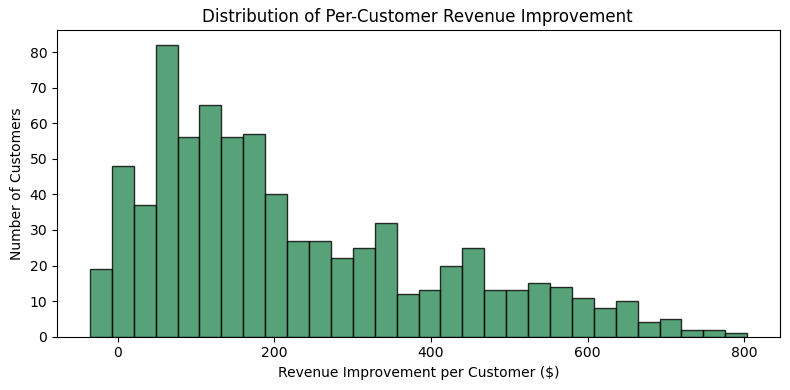

,OriginalRate,OptimalRate,OriginalRevenue,OptimalRevenue,RevenueImprovement
0,4.39,5.6,774.153022,968.766880,194.613859
1,6.34,4.8,383.461933,563.426171,179.964237
2,5.89,5.3,170.764868,880.294104,709.529236
3,5.99,5.9,771.338817,791.387370,20.048553
4,7.24,5.3,128.706842,932.493889,803.787048
5,8.49,5.5,44.005187,486.658030,442.652843
6,4.99,8.5,444.861770,730.908152,286.046382
7,6.44,5.5,65.892646,699.685442,633.792796
8,4.99,5.6,848.749808,928.132583,79.382775
9,8.65,5.5,56.231372,465.767552,409.536180


In [30]:
# --- Distribution of optimal rates ---
plt.figure(figsize=(8, 4))
plt.hist(q8_df['OptimalRate'], bins=np.arange(4.0, 8.6, 0.1),
         edgecolor='black', color='steelblue', alpha=0.8)
plt.xlabel('Optimal Rate (%)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Optimal Rates Across Test Customers')
plt.tight_layout()
plt.show()

# --- Revenue improvement per customer ---
plt.figure(figsize=(8, 4))
plt.hist(q8_df['RevenueImprovement'], bins=30, edgecolor='black',
         color='seagreen', alpha=0.8)
plt.xlabel('Revenue Improvement per Customer ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Per-Customer Revenue Improvement')
plt.tight_layout()
plt.show()

q8_df.head(10)

**Part 8 Results:**

Using the best model from Part 6, we optimized the APR for each customer in the test set by testing candidate rates from 4.0% to 8.5%. The total expected revenue at the original quoted rates is 383,213.32 dollars, while the total expected revenue at the optimized rates is 553,096.93 dollars. This implies a total expected revenue improvement of 169,883.61 dollars, or 44.33%.

**Part 9**: Using any of the methods covered in this course, further explore the eCar data to generate additional insights that eCar might find useful. “Negative” findings are acceptable here too – if you
expected to observe a particular relationship or result and your analysis surprisingly found none, that is valuable to know as well. Describe the significance of your findings in a few sentences.

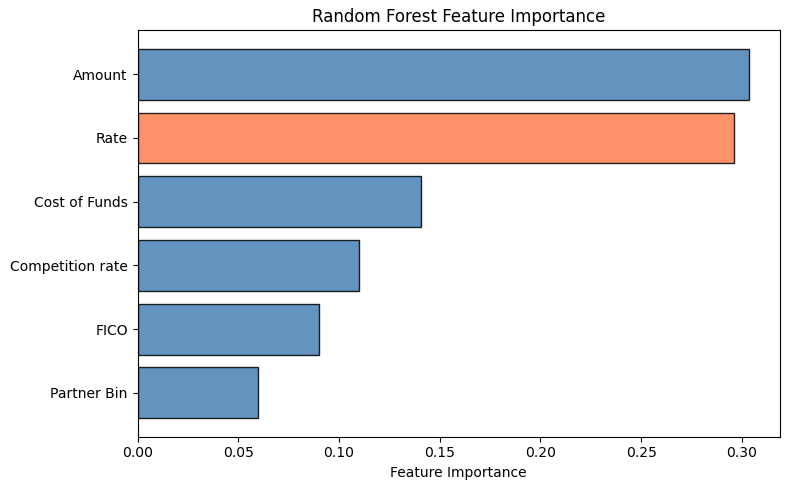

Feature Importances:
         Feature  Importance
          Amount    0.303720
            Rate    0.295926
   Cost of Funds    0.140646
Competition rate    0.109843
            FICO    0.090017
     Partner Bin    0.059848


In [31]:
# Part 9 - Insight A: Feature Importance from Random Forest

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Extract the best Random Forest from Part 6 grid search
rf_best = model_results['Random Forest'].best_estimator_

# Get feature importances
importances = rf_best.feature_importances_

# Get the actual feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Merge the three Partner Bin dummy variables into one
def merge_feature_name(name):
    if name.startswith('cat__Partner Bin'):
        return 'Partner Bin'
    elif name.startswith('num__'):
        return name.replace('num__', '')
    elif name.startswith('cat__'):
        return name.replace('cat__', '')
    else:
        return name

importance_df['Feature'] = importance_df['Feature'].apply(merge_feature_name)

# Aggregate importance by feature name
importance_df = (
    importance_df.groupby('Feature', as_index=False)['Importance']
    .sum()
    .sort_values('Importance', ascending=True)
)

# Plot
plt.figure(figsize=(8, 5))
colors = ['steelblue' if f != 'Rate' else 'coral' for f in importance_df['Feature']]
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color=colors, edgecolor='black', alpha=0.85)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importances:")
print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))

Silhouette scores: {2: 0.351, 3: 0.423, 4: 0.411, 5: 0.406, 6: 0.409, 7: 0.426}
Using k=3 for interpretability (silhouette: 0.423)


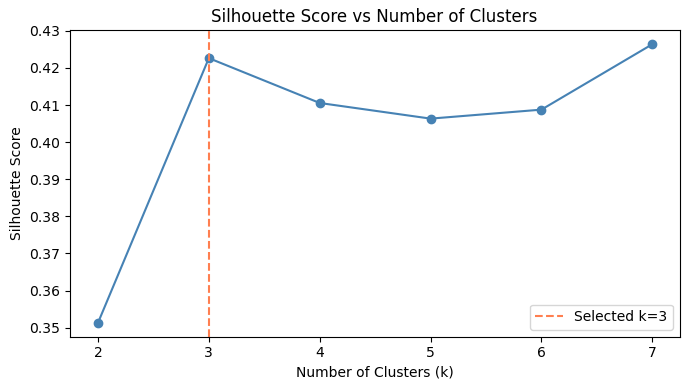

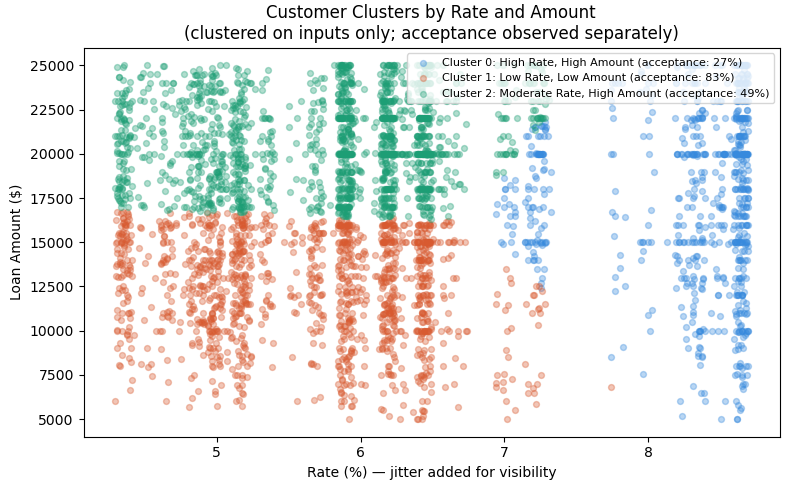

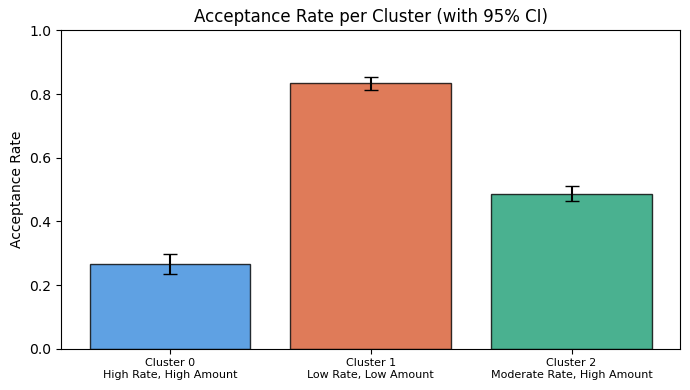


Cluster Summary:
         Count Acceptance Avg_Rate Avg_Amount                       Label
Cluster                                                                  
0          749      26.7%    8.28%    $17,516      High Rate, High Amount
1         1366      83.3%    5.63%    $12,310        Low Rate, Low Amount
2         1690      48.6%    5.77%    $20,691  Moderate Rate, High Amount


In [32]:
# Part 9 - Insight B: Customer Segmentation via K-Means Clustering (W10)
#
# Clustering is performed purely on Rate and Amount (inputs) — Acceptance is
# NOT used in clustering. We then observe how acceptance varies across the
# discovered groups to see if natural loan-offer patterns align with customer behavior.

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Use Amount and Rate — the top 2 features from Insight A
cluster_features = ['Amount', 'Rate']
X_cluster = data_trimmed[cluster_features].copy()

# Scale first — KMeans is distance-based so scaling matters
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# --- Step 1: Find optimal k using silhouette score ---
k_range = range(2, 8)
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    silhouette_scores.append(score)

# Force k=3 — nearly identical silhouette to k=7 but far more interpretable
best_k = 3
print(f"Silhouette scores: { {k: round(s,3) for k,s in zip(k_range, silhouette_scores)} }")
print(f"Using k={best_k} for interpretability (silhouette: {silhouette_scores[best_k-2]:.3f})")

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), silhouette_scores, marker='o', color='steelblue')
plt.axvline(best_k, color='coral', linestyle='--', label=f'Selected k={best_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.legend()
plt.tight_layout()
plt.show()

# --- Step 2: Fit final KMeans with k=3 ---
kmeans = KMeans(n_clusters=best_k, random_state=123, n_init=10)
data_trimmed = data_trimmed.copy()
data_trimmed['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

# --- Step 3: Build cluster summary first to get accurate labels ---
cluster_summary = data_trimmed.groupby('Cluster').agg(
    Count      = ('Accept?', 'count'),
    Acceptance = ('Accept?', 'mean'),
    Avg_Rate   = ('Rate', 'mean'),
    Avg_Amount = ('Amount', 'mean')
).round(3)

# Dynamically label clusters based on actual data
def label_cluster(row):
    if row['Avg_Rate'] >= 7.0:
        return 'High Rate, High Amount'
    elif row['Avg_Amount'] >= 18000:
        return 'Moderate Rate, High Amount'
    else:
        return 'Low Rate, Low Amount'

cluster_summary['Label'] = cluster_summary.apply(label_cluster, axis=1)
cluster_labels = cluster_summary['Label'].to_dict()

colors = ['#378ADD', '#D85A30', '#1D9E75']

# --- Step 4: Scatter plot with jitter — fix indexing bug ---
data_trimmed = data_trimmed.reset_index(drop=True)  # ensure positional index
np.random.seed(123)
jitter = np.random.uniform(-0.05, 0.05, size=len(data_trimmed))

plt.figure(figsize=(8, 5))
for c in range(best_k):
    mask     = data_trimmed['Cluster'] == c
    mask_idx = mask.values  # convert to numpy boolean for safe indexing
    acc_rate = data_trimmed.loc[mask, 'Accept?'].mean()
    plt.scatter(
        data_trimmed.loc[mask, 'Rate'].values + jitter[mask_idx],
        data_trimmed.loc[mask, 'Amount'].values,
        alpha=0.35, s=18,
        color=colors[c],
        label=f'Cluster {c}: {cluster_labels[c]} (acceptance: {acc_rate:.0%})'
    )

plt.xlabel('Rate (%) — jitter added for visibility')
plt.ylabel('Loan Amount ($)')
plt.title('Customer Clusters by Rate and Amount\n(clustered on inputs only; acceptance observed separately)')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

# --- Step 5: Acceptance rate per cluster with confidence intervals ---
plt.figure(figsize=(7, 4))
xtick_labels = []
for c in range(best_k):
    mask         = data_trimmed['Cluster'] == c
    cluster_data = data_trimmed.loc[mask, 'Accept?']
    avg = cluster_data.mean()
    se  = cluster_data.std() / np.sqrt(mask.sum())
    plt.bar(c, avg, color=colors[c], edgecolor='black', alpha=0.8)
    plt.errorbar(c, avg, yerr=1.96*se, fmt='none',
                 color='black', capsize=5, linewidth=1.5)
    xtick_labels.append(f'Cluster {c}\n{cluster_labels[c]}')

plt.xticks([0, 1, 2], xtick_labels, fontsize=8)
plt.ylabel('Acceptance Rate')
plt.title('Acceptance Rate per Cluster (with 95% CI)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# --- Step 6: Print summary table ---
cluster_summary_print = cluster_summary.copy()
cluster_summary_print['Acceptance'] = cluster_summary_print['Acceptance'].map('{:.1%}'.format)
cluster_summary_print['Avg_Rate']   = cluster_summary_print['Avg_Rate'].map('{:.2f}%'.format)
cluster_summary_print['Avg_Amount'] = cluster_summary_print['Avg_Amount'].map('${:,.0f}'.format)

print("\nCluster Summary:")
print(cluster_summary_print.to_string())

**Part 9 Findings**:

**1.** Random Forest feature importance shows that Amount and Rate are the two most important predictors of whether a customer accepts the loan. Amount has the highest importance at about 30.4%, and Rate is very close behind at about 29.6%. Together, these two variables account for about 60.0% of the model’s predictive importance. This suggests that e-Car should not evaluate APR by itself, because the impact of a rate depends heavily on the size of the loan. Cost of Funds is the third most important variable at about 14.1%, followed by Competition Rate at about 11.0% and FICO at about 9.0%. Partner Bin has the lowest importance at about 6.0%, suggesting that the customer acquisition channel is less informative than the loan amount, APR, funding cost, and customer credit characteristics.

**2.** KMeans clustering based only on Rate and Amount identifies three meaningful customer-offer groups. Cluster 1 includes customers with low rates and smaller loan amounts, with an average rate of 5.63%, an average loan amount of 12,310 dollars, and the highest acceptance rate of 83.3%. These offers are relatively affordable, so customers are much more likely to accept them. Cluster 2 includes customers with moderate rates and larger loan amounts, with an average rate of 5.77%, an average loan amount of 20,691 dollars, and a middle acceptance rate of 48.6%. This suggests that even when the APR is not very high, a larger loan amount can make the offer harder to accept. Cluster 0 includes customers with high rates, with an average rate of 8.28%, an average loan amount of 17,516 dollars, and the lowest acceptance rate of 26.7%. This shows that high APRs strongly reduce customer acceptance. Overall, Rate and Amount should be considered together when e-Car optimizes pricing, because customer acceptance depends on both the price of the loan and the affordability of the total loan amount.

**Part 10**: If you wanted to strengthen your study of eCar’s business, what additional aspects of the auto loan industry would you want to consider? What kind of additional data might be helpful? You don’t have to do any modeling here – just describe what kind of data and/or analysis might help deepen your investigation of e-Car’s business.

- Observation:

    The model results show that Amount and Rate are the two strongest predictors of customer acceptance, while Competition Rate and FICO score have weaker predictive power. This suggests an information gap: e-Car likely uses a general or lagged competitor rate rather than the actual offer a specific customer receives. At the same time, optimization results reveal a clear gap between quoted and optimal rates, indicating that current pricing does not fully capture individual willingness to pay. Additionally, the dataset lacks key drivers of affordability and risk, such as debt-to-income and vehicle-specific collateral value (i.e., age, mileage, loan-to-value), even though the case highlights that loan risk depends on both borrower and vehicle characteristics.

- Recommendation:

    e-Car should move to a dynamic, personalized pricing system that incorporates:

    1. Real-time or customer-level competitor offer data (not just market averages)
    2. Debt-to-income (DTI) to capture affordability and price sensitivity
    3. Loan-to-value (LTV) and vehicle characteristics (age, mileage, resale value)

    This system should be updated continuously (i.e., monthly) to reflect macroeconomic changes, such as shifts in the cost of funds or the interest rate environment.

- Rationale:

    The weak impact of the Competition Rate suggests that e-Car is not accurately capturing the true outside option for each customer. If e-Car had real-time competitor offers, it could price just below a customer’s next-best alternative, significantly improving conversion without unnecessary margin loss. At the same time, optimization results show that e-Car is both overpricing and underpricing different customers, which is consistent with the case’s critique of broad risk-based pricing that ignores demand-side behavior. Adding DTI and LTV improves the model by separating: Customers who cannot afford the loan (credit constraint) and customers who reject due to price sensitivity (demand behavior). Finally, incorporating macroeconomic variables ensures pricing remains accurate as borrowing conditions change, since customer sensitivity to APR differences can shift when interest rates rise. Together, these improvements enable e-Car to better balance margin vs. volume, aligning pricing with each customer’s true willingness to pay and maximizing long-term profitability.